# Library

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Data read

In [2]:
df = pd.read_csv("dataset/Earthquake.csv")

print("Shape of dataset (rows, columns):", df.shape)

print(df.head())

Shape of dataset (rows, columns): (17100, 22)
                       time  latitude  longitude    depth  mag magType    nst  \
0  2026-05-30T21:15:59.807Z   38.3564    73.8219  131.794  4.9      mb   80.0   
1  2026-05-29T12:22:54.128Z   23.4621    93.7220   57.374  4.3      mb   32.0   
2  2026-05-28T02:37:50.460Z   33.1393    96.1517   10.000  4.7      mb  111.0   
3  2026-05-26T16:30:57.714Z   23.1849    94.5425  102.712  4.3      mb   21.0   
4  2026-05-26T14:07:51.354Z   23.7982    94.8304  112.776  4.5      mb   36.0   

     gap   dmin   rms  ...                   updated  \
0   78.0  1.052  0.94  ...  2026-05-30T21:35:21.040Z   
1  126.0  2.503  0.68  ...  2026-05-29T12:58:49.040Z   
2   47.0  5.492  0.73  ...  2026-05-28T05:26:32.040Z   
3  158.0  2.000  0.43  ...  2026-05-27T14:59:41.040Z   
4   68.0  2.581  0.40  ...  2026-05-26T17:07:05.040Z   

                                   place        type horizontalError  \
0       24 km NNW of Murghob, Tajikistan  earthquake      

# Cleaning

In [3]:
df_cleaned = df.dropna(subset=['latitude', 'longitude', 'depth', 'mag']).drop_duplicates()

# Feature Engineering

In [4]:
X = df_cleaned[['latitude', 'longitude', 'depth']]
y = df_cleaned['mag']

# Data Splitting for train and test set

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model Training

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# root mean square

In [7]:
y_pred = lr_model.predict(X_test)

# 3. Regression Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}\n")

Linear Regression Metrics:
RMSE: 0.4093
R2 Score: 0.0028



# Confusion Matrix

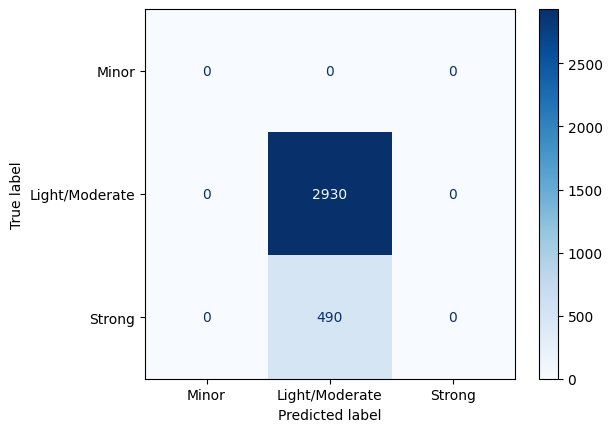

In [8]:
def bin_magnitude(val):
    if val < 3.0:
        return 'Minor'
    elif val < 5.0:
        return 'Light/Moderate'
    else:
        return 'Strong'

# Apply binning to actual and predicted values
y_test_binned = y_test.apply(bin_magnitude)
y_pred_binned = pd.Series(y_pred, index=y_test.index).apply(bin_magnitude)

labels = ['Minor', 'Light/Moderate', 'Strong']
cm = confusion_matrix(y_test_binned, y_pred_binned, labels=labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')

# Prediction

In [9]:
def predict_new_coordinate(latitude, longitude, depth):
    input_data = pd.DataFrame([[latitude, longitude, depth]], columns=['latitude', 'longitude', 'depth'])
    predicted_mag = lr_model.predict(input_data)[0]
    risk_class = bin_magnitude(predicted_mag)
    
    return {
        "Predicted Magnitude": round(predicted_mag, 2),
        "Risk Category": risk_class
    }

# Example deployment test call:
print(predict_new_coordinate(34.0522, -118.2437, 12.5))

{'Predicted Magnitude': np.float64(4.26), 'Risk Category': 'Light/Moderate'}
